In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\sanch\\OneDrive\\Desktop\\flight-delay-intelligence\\data\\cleaned\\featured_flights.csv")

In [3]:
df.head()

,Used Date,From,To,Airline,Scheduled Departure,SDEP,Departure,DEP,Scheduled Arrival,SARR,...,Category,Month,Day,Weekday,Is_Weekend,Total Delay,Delay Category,Route,Peak Hour,Weather Severity
0,2020-01-31,DEL,HYD,Air Asia,6:05,605,6:04,604.0,8:15,815,...,0,1,31,Friday,False,2.0,Minor Delay,DEL-HYD,Morning Peak,21.3
1,2020-01-31,DEL,HYD,Indigo,4:50,450,4:36,436.0,7:00,700,...,0,1,31,Friday,False,-19.0,Minor Delay,DEL-HYD,Off Peak,21.3
2,2020-01-30,DEL,HYD,Air Asia,6:05,605,5:54,554.0,8:15,815,...,0,1,30,Thursday,False,-24.0,Minor Delay,DEL-HYD,Morning Peak,21.3
3,2020-01-30,DEL,HYD,Air Asia,17:40,1740,17:40,1740.0,19:55,1955,...,0,1,30,Thursday,False,-13.0,Minor Delay,DEL-HYD,Evening Peak,21.3
4,2020-01-30,DEL,HYD,Air Asia,19:50,1950,19:54,1954.0,22:10,2210,...,1,1,30,Thursday,False,8.0,Minor Delay,DEL-HYD,Evening Peak,21.3


In [4]:
df.columns.tolist()

['Used Date',
 'From',
 'To',
 'Airline',
 'Scheduled Departure',
 'SDEP',
 'Departure',
 'DEP',
 'Scheduled Arrival',
 'SARR',
 'Arrival',
 'ARR',
 'Departure Delay',
 'Arrival Delay',
 'Status',
 'Distance',
 'Passenger Load Factor',
 'Airline Rating',
 'Airport Rating',
 'Market Share',
 'OTP Index',
 'weather__hourly__windspeedKmph',
 'weather__hourly__weatherDesc__value',
 'weather__hourly__precipMM',
 'weather__hourly__humidity',
 'weather__hourly__visibility',
 'weather__hourly__pressure',
 'weather__hourly__cloudcover',
 'Category',
 'Month',
 'Day',
 'Weekday',
 'Is_Weekend',
 'Total Delay',
 'Delay Category',
 'Route',
 'Peak Hour',
 'Weather Severity']

### Airline Arrival Delay Analysis by Airline

In [5]:
airline_delay = df.groupby("Airline")["Arrival Delay"].mean().sort_values(ascending=False)

print("Arrival delay in minutes: \n",airline_delay)

Arrival delay in minutes: 
 Airline
Air India    56.010494
SpiceJet     45.947917
Go Air       36.518145
Spicejet     23.715423
Air Asia     22.703196
Vistara      19.105606
Indigo       18.602074
Name: Arrival Delay, dtype: float64


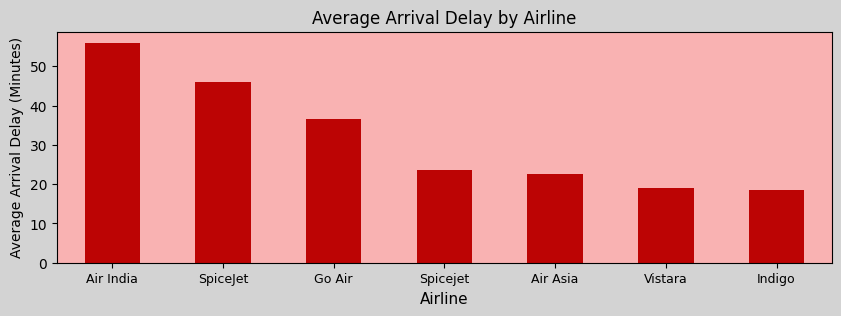

In [6]:
plt.figure(figsize=(10,3), facecolor="lightgray")
ax = airline_delay.plot(
    kind="bar",
    color="#BC0404"
)

ax.set_facecolor("#F9B2B2")
plt.title("Average Arrival Delay by Airline")
plt.xlabel("Airline",fontsize=11)
plt.ylabel("Average Arrival Delay (Minutes)")
plt.xticks(rotation=0,fontsize=9)


plt.show()

##### Insight :

In [7]:
# - Air India has the highest average arrival delay among all airlines.
# - Indigo and Vistara show comparatively lower arrival delays, indicating better operational efficiency.
# - Go Air and SpiceJet fall in the middle range of delay performance.
# - Airlines with consistently high delays may be affected by congestion, scheduling inefficiencies, or operational challenges.

### Departure Delay Analysis by Airline

In [8]:
departure_delay = df.groupby("Airline")["Departure Delay"].mean().sort_values(ascending=False)

print("departure delay in minutes :\n",departure_delay) 

departure delay in minutes :
 Airline
Air India    51.708642
SpiceJet     36.500000
Go Air       23.992944
Indigo       22.470995
Air Asia     21.998478
Spicejet     21.649751
Vistara      13.641460
Name: Departure Delay, dtype: float64


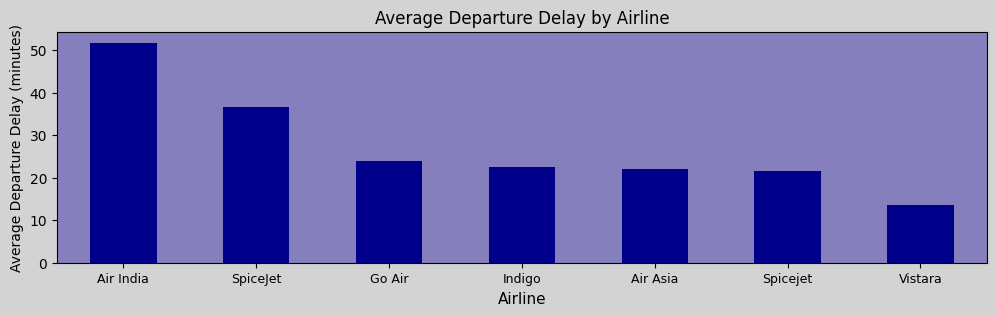

In [9]:
plt.figure(figsize=(12,3), facecolor="lightgray")

ax = departure_delay.plot(
    kind="bar",
    color="#00008B"
)

ax.set_facecolor("#8580BD")
plt.title("Average Departure Delay by Airline")
plt.xlabel("Airline",fontsize=11)
plt.ylabel("Average Departure Delay (minutes)")
plt.xticks(rotation=0,fontsize=9)

plt.show()

##### Insight

In [10]:
# - Air India also records the highest average departure delay.
# - Vistara has the lowest departure delay, showing stronger departure-time management.
# - High departure delays often propagate into arrival delays.
# - Operational efficiency before takeoff plays a major role in overall flight punctuality.

#### Airport Delay Analysis

In [11]:
airport_delay = df.groupby("From")["Arrival Delay"].mean().sort_values(ascending=False)

airport_delay

From
BOM    49.691429
CCU    38.970615
DEL    29.955588
BLR    17.483417
Name: Arrival Delay, dtype: float64

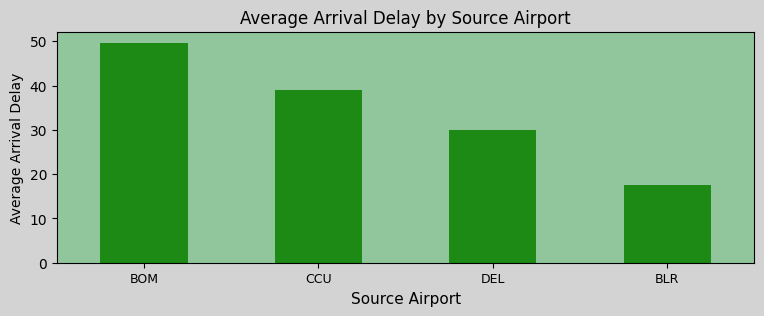

In [12]:
plt.figure(figsize=(9,3), facecolor="lightgray")

ax = airport_delay.plot(
    kind="bar",
    color="#1C8A14"
)

ax.set_facecolor("#91C69D")

plt.title("Average Arrival Delay by Source Airport")
plt.xlabel("Source Airport",fontsize=11)
plt.ylabel("Average Arrival Delay")

plt.xticks(rotation=0,fontsize=9)

plt.show()

##### Insight

In [13]:
# - BOM airport shows the highest average arrival delay among the analyzed source airports.
# - BLR has the lowest average delay, indicating relatively smoother operations.
# - DEL and CCU experience moderate delays.
# - Airport congestion, traffic volume, and operational capacity may influence these delay patterns.

#### Weather Impact Analysis

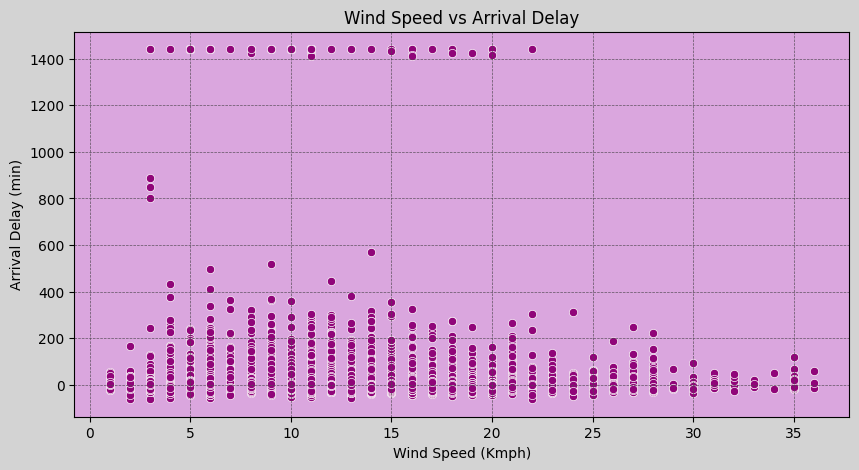

In [14]:
# Windspeed vs Arrival Delay

plt.figure(figsize=(10,5), facecolor="lightgray")

ax = sns.scatterplot(
    x=df["weather__hourly__windspeedKmph"],
    y=df["Arrival Delay"],
    color="#900579"
)

ax.set_facecolor("#DAA6DE")

plt.title("Wind Speed vs Arrival Delay")
plt.xlabel("Wind Speed (Kmph)")
plt.ylabel("Arrival Delay (min)")

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)
plt.show()

##### Insight :

In [15]:
# - There is no strong linear relationship between wind speed and arrival delay.
# - However, some extreme delays occur at moderate wind speeds.
# - This suggests that wind speed alone may not be the primary cause of delays.
# - Other operational or weather-related factors may contribute more significantly.

#### Visibility vs Delay

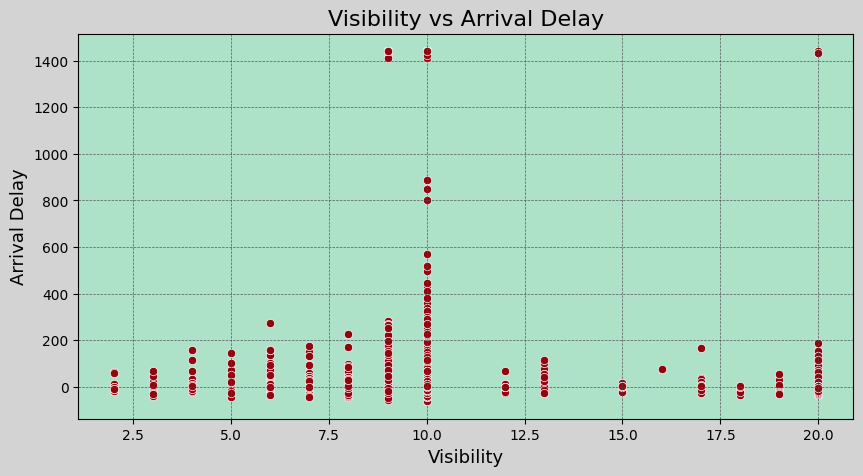

In [16]:
plt.figure(figsize=(10,5), facecolor="lightgray")

ax = sns.scatterplot(
    x=df["weather__hourly__visibility"],
    y=df["Arrival Delay"],
    color="#90050E"
)

ax.set_facecolor("#ADE2C9")

plt.title("Visibility vs Arrival Delay",fontsize=16)

plt.xlabel("Visibility",fontsize=13)

plt.ylabel("Arrival Delay",fontsize=13)

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5)

plt.show()

In [17]:
# Visibility shows only a weak relationship with arrival delay. 
# Severe delays appear even during moderate visibility conditions, indicating that operational and 
# scheduling factors may have a stronger impact than visibility alone.

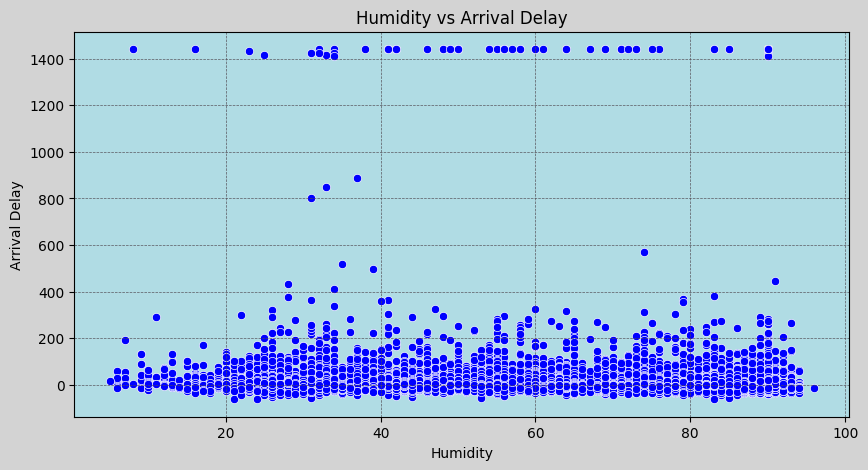

In [18]:
# Humidity vs Arrival Delay


plt.figure(figsize=(10,5), facecolor="lightgray")

ax = sns.scatterplot(
    x=df["weather__hourly__humidity"],
    y=df["Arrival Delay"],
    color="blue"
)

ax.set_facecolor("#B0DCE4")

plt.title("Humidity vs Arrival Delay")
plt.xlabel("Humidity")
plt.ylabel("Arrival Delay")

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)

plt.show()

##### Insight :

In [19]:
# - Arrival delays are distributed across all humidity levels.
# - Extremely large delays appear at moderate-to-high humidity conditions.
# - Humidity may contribute indirectly to operational disruptions, but the correlation appears weak.
# - Most flights still experience relatively low delays regardless of humidity level.

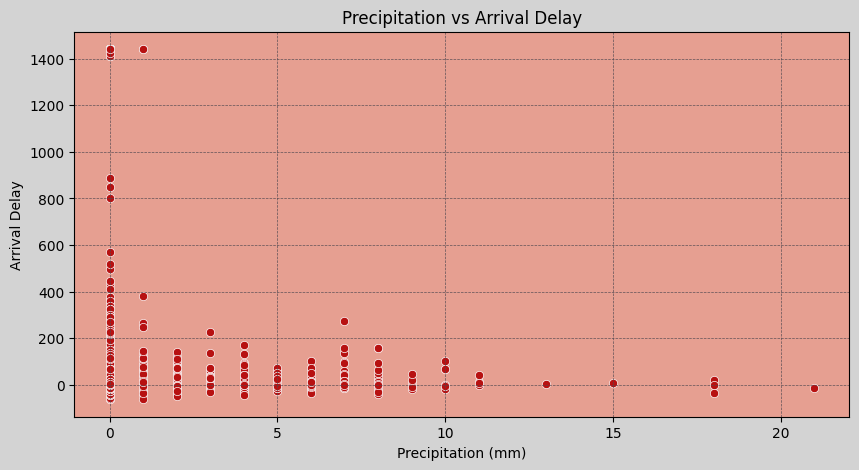

In [20]:
# Precipitation vs Arrival Delay


plt.figure(figsize=(10,5), facecolor="lightgray")

ax = sns.scatterplot(
    x=df["weather__hourly__precipMM"],
    y=df["Arrival Delay"],
    color="#B71111"
)

ax.set_facecolor("#E69F91")

plt.title("Precipitation vs Arrival Delay")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Arrival Delay")

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)

plt.show()

##### Insight :

In [21]:
# - Higher precipitation levels generally correspond to lower concentrations of flights.
# - Some severe delays occur during very low or zero precipitation conditions.
# - Heavy rainfall may reduce flight frequency, while operational disruptions may still happen during light precipitation.
# - Precipitation alone does not fully explain delay severity.

#### Time Trend Analysis

In [22]:
df['Used Date'].info

<bound method Series.info of 0        2020-01-31
1        2020-01-31
2        2020-01-30
3        2020-01-30
4        2020-01-30
            ...    
10703    2019-01-24
10704    2019-01-23
10705    2019-01-22
10706    2019-09-01
10707    2019-02-01
Name: Used Date, Length: 10708, dtype: object>

In [23]:
df["Used Date"] = pd.to_datetime(df["Used Date"])

In [24]:
# Daily Average Delay Trend


daily_delay = df.groupby("Used Date")["Arrival Delay"].mean()

daily_delay.head()

Used Date
2019-01-02     -9.000000
2019-01-03    222.000000
2019-01-06     -6.500000
2019-01-07     22.000000
2019-01-09     -8.866667
Name: Arrival Delay, dtype: float64

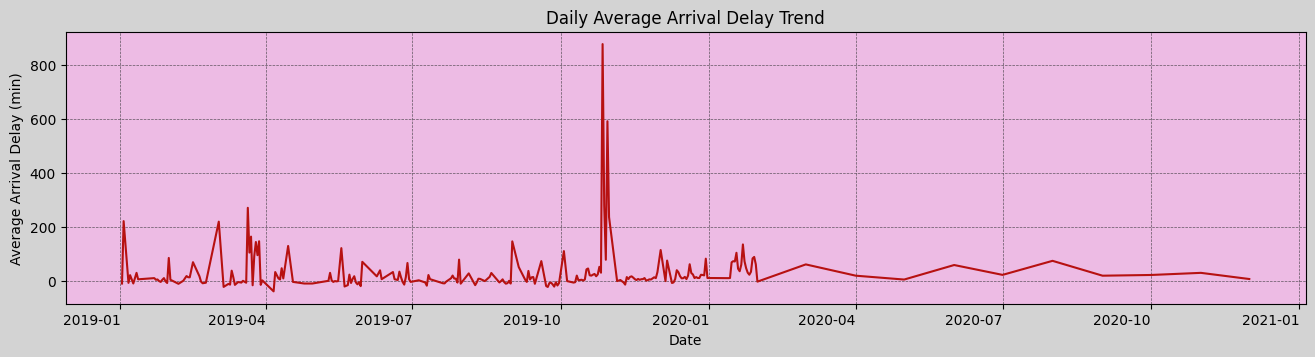

In [25]:
plt.figure(figsize=(16,4), facecolor="lightgray")

ax = daily_delay.plot(
    kind="line",
    color="#B71111")

ax.set_facecolor("#EDBBE4")

plt.title("Daily Average Arrival Delay Trend")
plt.xlabel("Date")
plt.ylabel("Average Arrival Delay (min)")

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)
plt.xticks(rotation=0)

plt.show()

##### Insight :

In [26]:
# - Arrival delays fluctuate significantly over time.
# - Several sharp spikes indicate isolated periods of severe disruption.
# - One major spike suggests an extreme operational event, weather issue, or airport congestion episode.
# - Most days maintain relatively moderate average delays.
# - Delay patterns are highly variable rather than consistently increasing or decreasing over time.

#### Monthly Delay Analysis

In [27]:
monthly_delay = df.groupby("Month")["Total Delay"].mean()

monthly_delay

Month
1     100.493895
2      34.374532
3      66.175610
4      57.604027
5      32.726688
6      48.860902
7      29.067857
8      15.818991
9      41.297214
10     80.622000
11     22.942172
12     43.289943
Name: Total Delay, dtype: float64

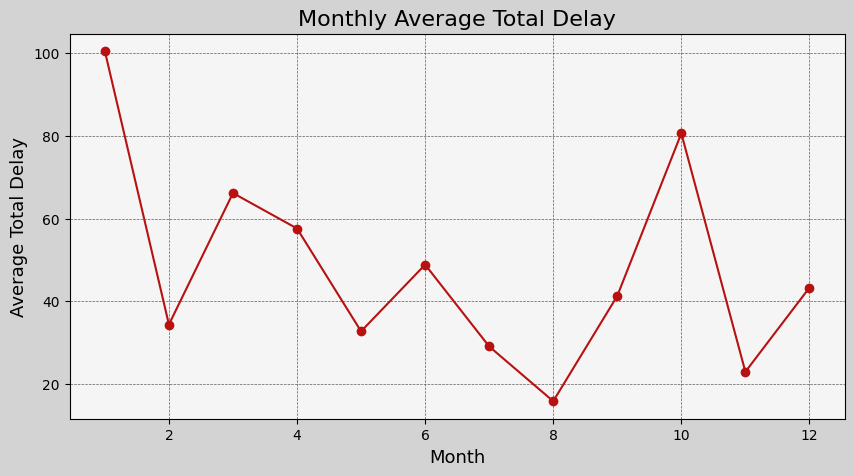

In [28]:
plt.figure(figsize=(10,5), facecolor="lightgray")

ax = monthly_delay.plot(kind="line",color="#B71111",marker="o")

ax.set_facecolor("whitesmoke")

plt.title("Monthly Average Total Delay",fontsize=16)
plt.xlabel("Month",fontsize=13)
plt.ylabel(
    "Average Total Delay",
    fontsize=13
)

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)

plt.show()

##### Insight :

In [29]:
# Airline delays exhibit strong seasonal behavior,
# with January and October experiencing the highest operational delays, 
# while August shows comparatively efficient performance and lower congestion.

#### Peak Hour Congestion

In [30]:
peak_hour = df["Peak Hour"].value_counts()

peak_hour

Peak Hour
Off Peak        5374
Morning Peak    2693
Evening Peak    2641
Name: count, dtype: int64

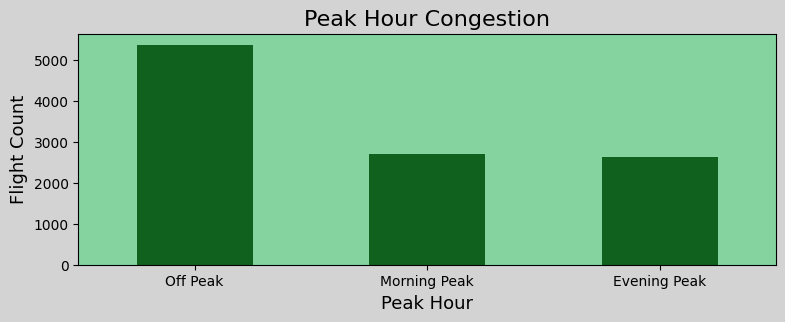

In [31]:
plt.figure(figsize=(9,3), facecolor="lightgray")

ax = peak_hour.plot(kind="bar",color="#085814EC")

ax.set_facecolor("#85D4A0")

plt.title("Peak Hour Congestion",fontsize=16)
plt.xlabel("Peak Hour",fontsize=13)
plt.ylabel("Flight Count",fontsize=13)

plt.xticks(rotation=0)

plt.show()

##### Insight :

In [32]:
# Flight operations are concentrated mainly during Off Peak periods, 
# while Morning and Evening Peak hours experience balanced but dense traffic patterns that may increase operational congestion and delay risk.

#### Delay Distribution

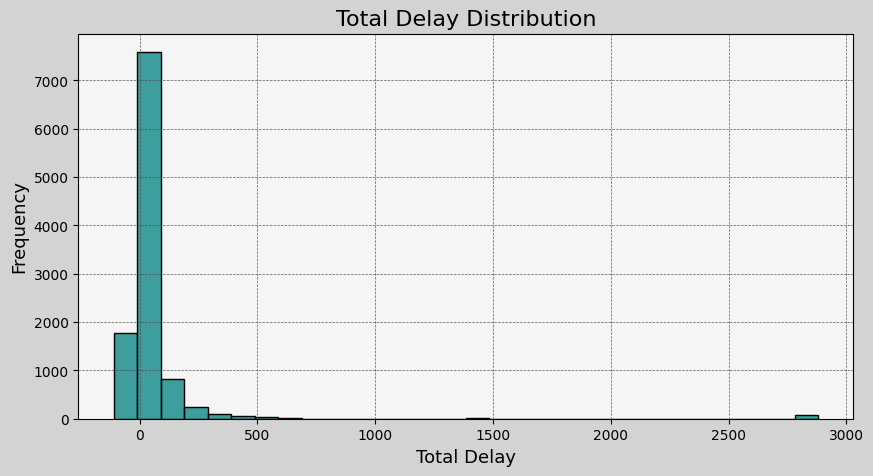

In [33]:
plt.figure(figsize=(10,5), facecolor="lightgray")

ax = sns.histplot(df["Total Delay"],bins=30,color="teal")

ax.set_facecolor("whitesmoke")

plt.title("Total Delay Distribution",fontsize=16)
plt.xlabel("Total Delay",fontsize=13)
plt.ylabel("Frequency",fontsize=13)

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)


plt.show()

##### Insight :

In [34]:
# Most flights experience low or moderate delays, 
# but the dataset contains a small number of extreme operational disruptions that heavily influence the overall delay distribution.

#### Box Plot

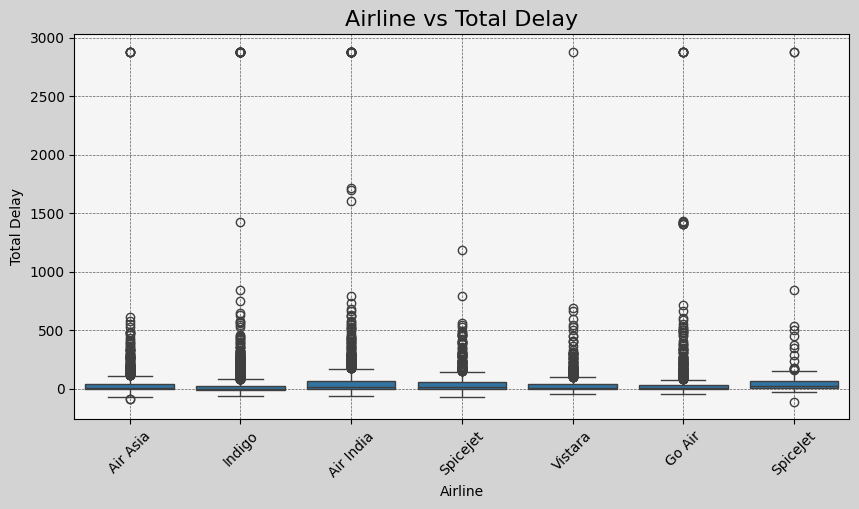

In [35]:
plt.figure(figsize=(10,5), facecolor="lightgray")

ax = sns.boxplot(x=df["Airline"],y=df["Total Delay"])

ax.set_facecolor("whitesmoke")
plt.title("Airline vs Total Delay",fontsize=16)

plt.xticks(rotation=45)

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)

plt.show()

##### Insight :

In [36]:
# Although most airlines maintain relatively stable average operations, 
# some airlines exhibit higher variability and more extreme delay events, indicating differences in operational reliability and congestion management.

#### Busiest Source Airport

In [37]:
busy_airport = df["From"].value_counts()

busy_airport

From
BLR    5397
CCU    2212
DEL    2049
BOM    1050
Name: count, dtype: int64

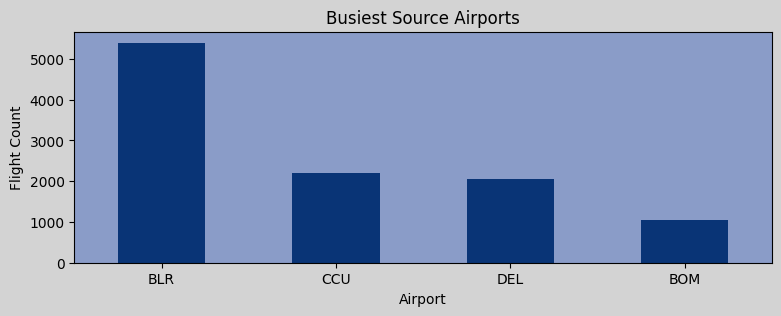

In [38]:
plt.figure(figsize=(9,3), facecolor="lightgray")

ax = busy_airport.plot(kind="bar",color="#093476")

ax.set_facecolor("#8A9CC8")

plt.title("Busiest Source Airports")
plt.xlabel("Airport")
plt.ylabel("Flight Count")

plt.xticks(rotation=0)

plt.show()

##### Insight :

In [39]:
# BLR emerges as the dominant operational hub in the dataset, 
# handling the highest flight volume and potentially facing greater congestion and operational complexity compared to other airports.

#### Problematic Routes

In [40]:
route_delay = df.groupby("Route")["Total Delay"].mean().sort_values(ascending=False).head(10)

route_delay

Route
BOM-DEL    100.214286
CCU-DEL     77.050181
DEL-HYD     61.925329
BLR-DEL     34.233033
BLR-BOM     27.860901
Name: Total Delay, dtype: float64

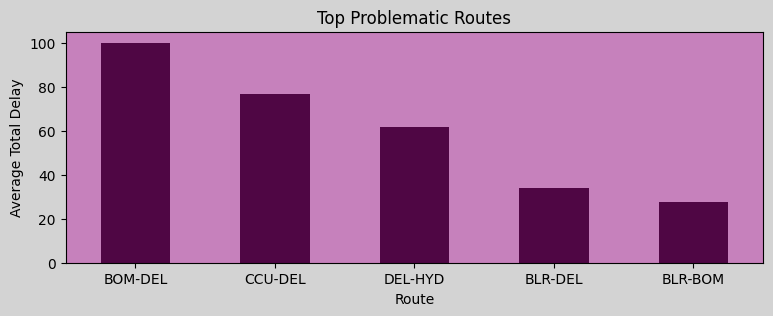

In [41]:
plt.figure(figsize=(9,3), facecolor="lightgray")

ax = route_delay.plot(kind="bar",color="#4F0644")

ax.set_facecolor("#C681BC")

plt.title("Top Problematic Routes")
plt.xlabel("Route")
plt.ylabel("Average Total Delay")

plt.xticks(rotation=0)

plt.show()

##### Insight :

In [42]:
#BOM → DEL emerges as the most delay-prone route, 
# while routes connected to DEL generally exhibit higher operational congestion and delay intensity.

##### Correlation Heatmap

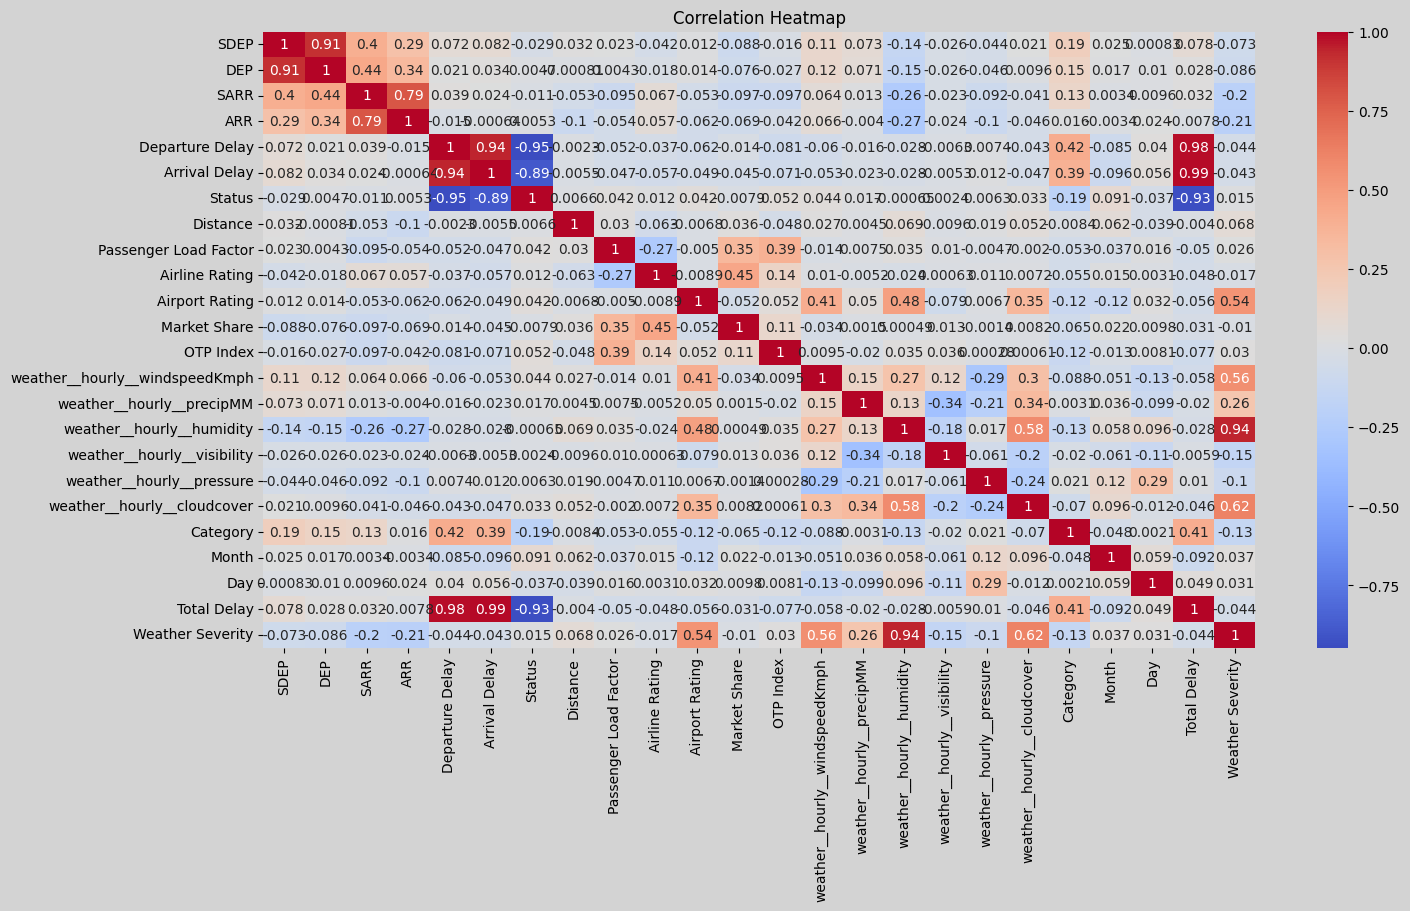

In [43]:
plt.figure(figsize=(16,8), facecolor="lightgray")

correlation = df.select_dtypes(include=["number"]).corr()

ax = sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

#### Delay Category Distribution

C:\Users\sanch\AppData\Local\Temp\ipykernel_13184\1132412824.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


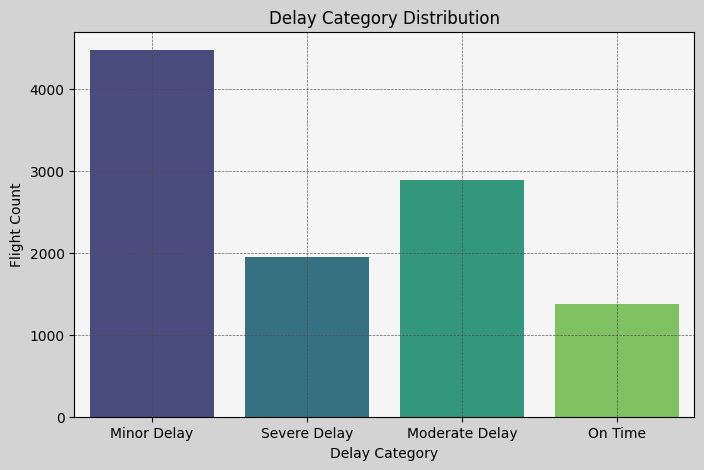

In [44]:
plt.figure(figsize=(8,5), facecolor="lightgray")

ax = sns.countplot(
    x=df["Delay Category"],
    palette="viridis"
)

ax.set_facecolor("#F5F5F5")

plt.title("Delay Category Distribution")
plt.xlabel("Delay Category")
plt.ylabel("Flight Count")

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)


plt.show()

##### Insight :

In [ ]:
# Most flights experience minor or moderate delays, 
# while fully on-time operations are relatively limited, indicating persistent operational congestion across the aviation network.

#### Weekday Delay Analysis

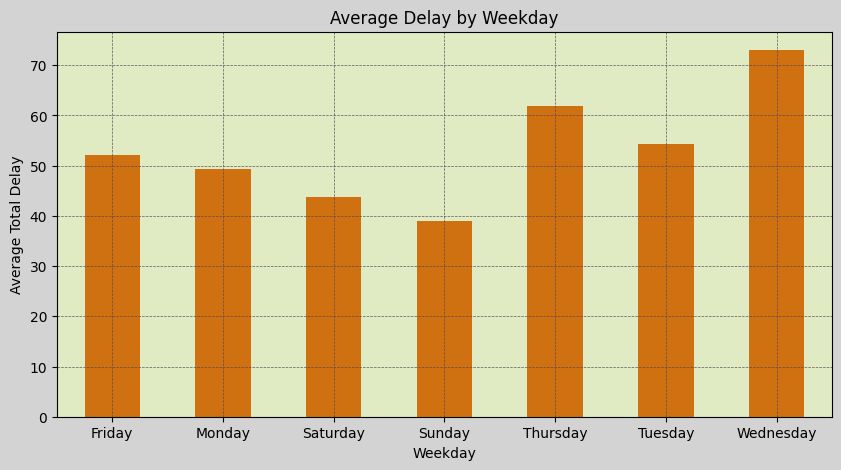

In [50]:
weekday_delay = df.groupby("Weekday")["Total Delay"].mean()

plt.figure(figsize=(10,5), facecolor="lightgray")

ax = weekday_delay.plot(
    kind="bar",
    color="#CF7011"
)

ax.set_facecolor("#E0EBC3")

plt.title("Average Delay by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Total Delay")

plt.xticks(rotation=0)

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)
plt.show()

##### Insight :

In [ ]:
#Mid-week operations, particularly Wednesday and Thursday, experience the highest average delays, 
# while Sunday appears to be the least congested operational day.

#### Monthly Flight Traffic

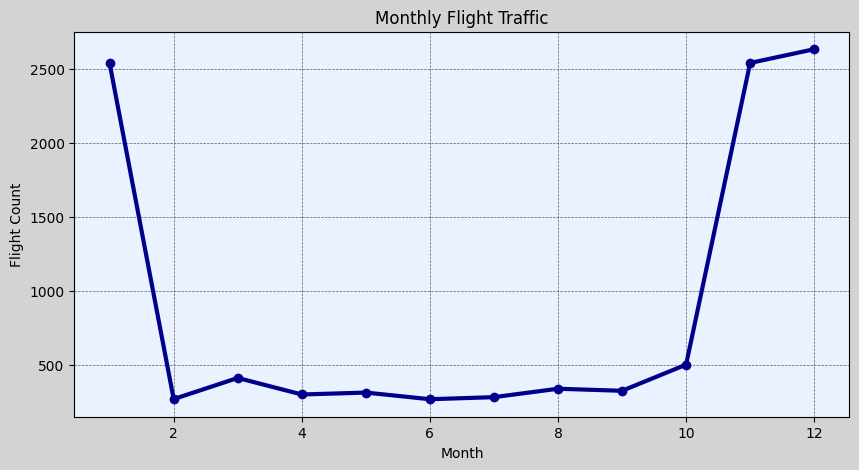

In [51]:
monthly_traffic = df["Month"].value_counts().sort_index()

plt.figure(figsize=(10,5), facecolor="lightgray")

ax = monthly_traffic.plot(
    kind="line",
    marker="o",
    color="darkblue",
    linewidth=3
)

ax.set_facecolor("#EAF2FF")

plt.title("Monthly Flight Traffic")
plt.xlabel("Month")
plt.ylabel("Flight Count")

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)

plt.show()

##### Insight :

In [ ]:
#Flight traffic demonstrates strong seasonal behavior, 
# with major operational peaks occurring in January and the November–December period.